Saving Q1_Hospital_ER_Dataset.csv to Q1_Hospital_ER_Dataset.csv
First 5 rows:
  PatientID  Age  Gender       ArrivalTime TriageLevel  WaitingTimeMinutes  \
0     P1001   52  Female   21/02/2026 3:00     Level 5               204.0   
1     P1002   15  Female   24/02/2026 8:15     Level 3                58.0   
2     P1003   72  Female   08/02/2026 4:55     Level 5                 NaN   
3     P1004   61  Female  04/02/2026 21:55     Level 3                66.0   
4     P1005   21   Other   18/02/2026 2:45     Level 1                29.0   

  DoctorAssigned AdmissionStatus  
0       Dr. Khan      Discharged  
1       Dr. Sara     Transferred  
2       Dr. Noor      Discharged  
3       Dr. Noor      Discharged  
4        Dr. Ali        admitted  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PatientID           88 

/tmp/ipykernel_353/3582340662.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_353/3582340662.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

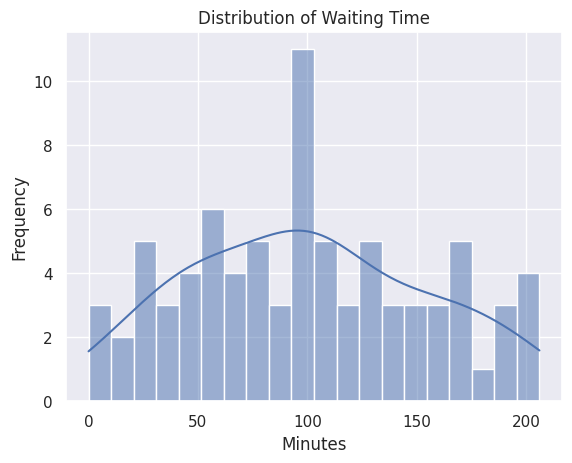

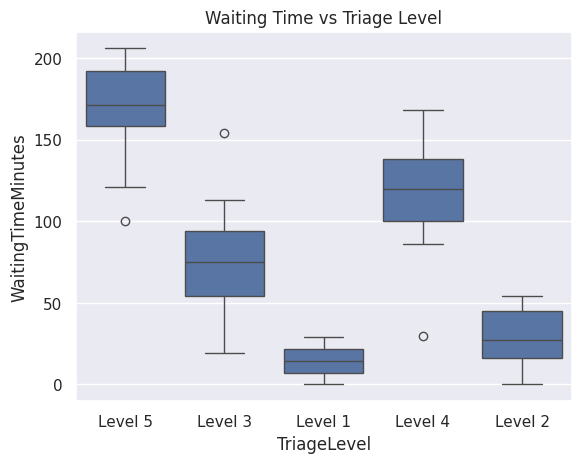

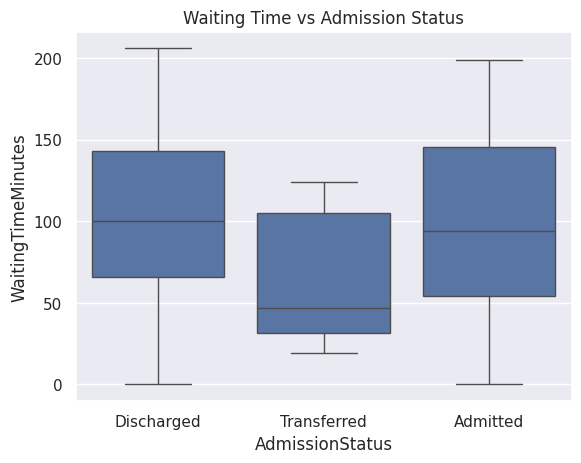


Final Cleaned Data:
  PatientID  Age  Gender       ArrivalTime TriageLevel  WaitingTimeMinutes  \
0     P1001   52  Female   21/02/2026 3:00     Level 5               204.0   
1     P1002   15  Female   24/02/2026 8:15     Level 3                58.0   
2     P1003   72  Female   08/02/2026 4:55     Level 5               100.0   
3     P1004   61  Female  04/02/2026 21:55     Level 3                66.0   
4     P1005   21   Other   18/02/2026 2:45     Level 1                29.0   

  DoctorAssigned AdmissionStatus  
0       Dr. Khan      Discharged  
1       Dr. Sara     Transferred  
2       Dr. Noor      Discharged  
3       Dr. Noor      Discharged  
4        Dr. Ali        Admitted  


In [ ]:
# STEP 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

# STEP 2. UPLOADING DATASET
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
print("First 5 rows:")
print(df.head())

# STEP 3. DATASET STRUCTURE
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe(include='all'))
print("\nUnique Values:")
for col in df.columns:
    print(col, ":", df[col].nunique())

# STEP 4. DATA QUALITY CHECKS

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Invalid Ages
if 'Age' in df.columns:
    invalid_age = df[(df['Age'] < 0) | (df['Age'] > 120)]
    print("\nInvalid Age Rows:")
    print(invalid_age)

# Category inconsistencies
for col in ['Gender', 'TriageLevel', 'AdmissionStatus']:
    if col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].unique())

# STEP 5. DATA CLEANING

# Handle missing values
if 'Age' in df.columns:
    df['Age'].fillna(df['Age'].median(), inplace=True)

if 'WaitingTimeMinutes' in df.columns:
    df['WaitingTimeMinutes'].fillna(df['WaitingTimeMinutes'].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix invalid ages
if 'Age' in df.columns:
    df = df[(df['Age'] >= 0) & (df['Age'] <= 120)]

# Standardize categories
for col in ['Gender', 'AdmissionStatus', 'TriageLevel']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.capitalize()

# STEP 6. OUTLIER REMOVAL (IQR)
if 'WaitingTimeMinutes' in df.columns:
    Q1 = df['WaitingTimeMinutes'].quantile(0.25)
    Q3 = df['WaitingTimeMinutes'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df['WaitingTimeMinutes'] >= lower) &
            (df['WaitingTimeMinutes'] <= upper)]

print("\nData cleaned successfully!")

# STEP 7. UNIVARIATE ANALYSIS FOR WaitingTimeMinutes
plt.figure()
sns.histplot(df['WaitingTimeMinutes'], bins=20, kde=True)
plt.title("Distribution of Waiting Time")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

# STEP 8. BIVARIATE ANALYSIS

# Waiting Time vs Triage Level
if 'TriageLevel' in df.columns:
    plt.figure()
    sns.boxplot(x='TriageLevel', y='WaitingTimeMinutes', data=df)
    plt.title("Waiting Time vs Triage Level")
    plt.show()

# Waiting Time vs Admission Status
if 'AdmissionStatus' in df.columns:
    plt.figure()
    sns.boxplot(x='AdmissionStatus', y='WaitingTimeMinutes', data=df)
    plt.title("Waiting Time vs Admission Status")
    plt.show()

# STEP 9. FINAL CLEAN DATA
print("\nFinal Cleaned Data:")
print(df.head())

Saving Q2_Ecommerce_Returns_Dataset.csv to Q2_Ecommerce_Returns_Dataset (1).csv
Preview:
  OrderID CustomerRegion ProductCategory  OrderValue  DeliveryDays  \
0   O5001           East         Fashion      215.44           6.0   
1   O5002          North         Fashion      269.86           2.0   
2   O5003           East     Electronics      267.41           7.0   
3   O5004           West            Home      103.40           2.0   
4   O5005           East          Beauty       32.82          11.0   

   DiscountPercent Returned PaymentMethod  
0               40       No        Wallet  
1               25      Yes          Card  
2               50       No          Card  
3              110      Yes           COD  
4               10       No        Wallet  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID     

/tmp/ipykernel_353/1789520691.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_353/1789520691.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

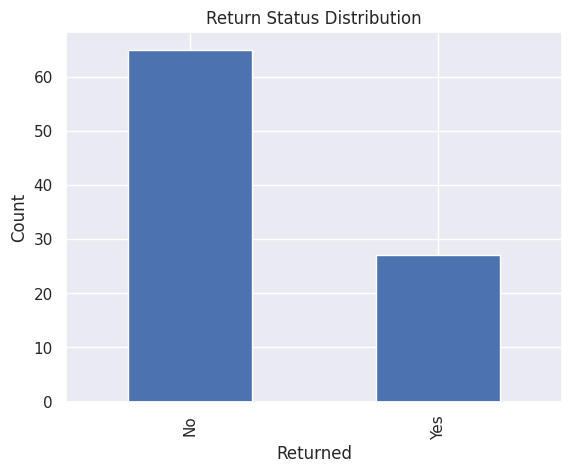

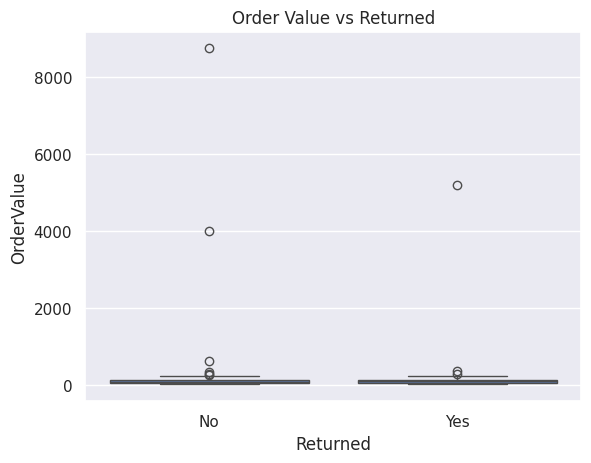

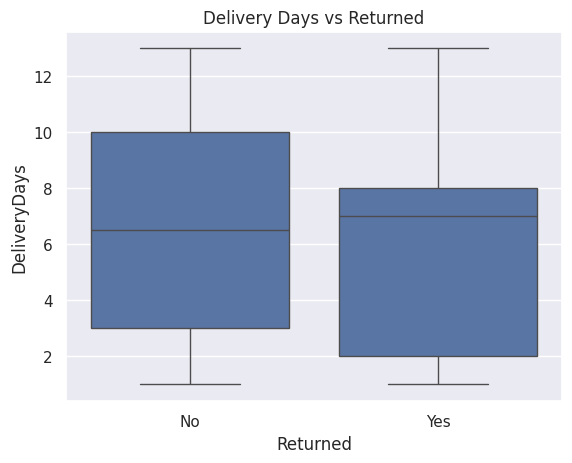

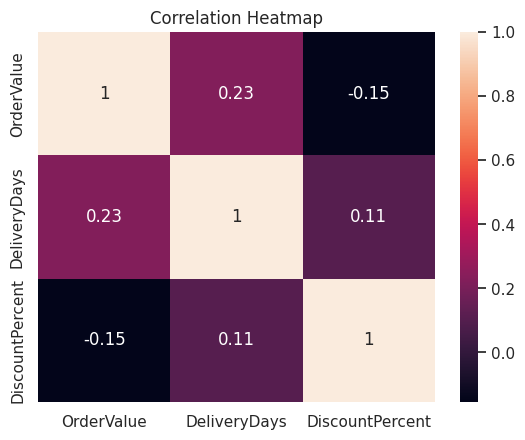


Final Data Preview:
  OrderID CustomerRegion ProductCategory  OrderValue  DeliveryDays  \
0   O5001           East         Fashion      215.44           6.0   
1   O5002          North         Fashion      269.86           2.0   
2   O5003           East     Electronics      267.41           7.0   
4   O5005           East          Beauty       32.82          11.0   
5   O5006        Central            Home      355.28           2.0   

   DiscountPercent Returned  PaymentMethod  
0               40       No         Wallet  
1               25      Yes           Card  
2               50       No           Card  
4               10       No         Wallet  
5               10      Yes  Bank transfer  


In [ ]:
# STEP 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

# STEP 2. UPLOAD DATASET
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
print("Preview:")
print(df.head())

# STEP 3. DATASET STRUCTURE

print("\nDataset Info:")
df.info()

print("\nSummary:")
print(df.describe(include='all'))

# STEP 4. DATA QUALITY SUMMARY TABLE
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values,
    "Data Type": df.dtypes.values
})
print("\nData Quality Report:")
print(quality_report)

# STEP 5. DETECT ISSUES
# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Invalid discount (>100 or <0)
if 'DiscountPercent' in df.columns:
    print("\nInvalid Discounts:")
    print(df[(df['DiscountPercent'] < 0) | (df['DiscountPercent'] > 100)])

# Category inconsistencies
for col in ['Returned', 'PaymentMethod', 'ProductCategory', 'CustomerRegion']:
    if col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].unique())

# STEP 6. DATA CLEANING
# Fill missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix discount values
if 'DiscountPercent' in df.columns:
    df = df[(df['DiscountPercent'] >= 0) & (df['DiscountPercent'] <= 100)]

# Standardize categorical values
for col in ['Returned', 'PaymentMethod', 'ProductCategory', 'CustomerRegion']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.capitalize()

print("\nData cleaned!")

# STEP 7. FREQUENCY TABLE (Returned)
freq_table = df['Returned'].value_counts()
print("\nReturned Frequency Table:")
print(freq_table)

# Bar Chart
plt.figure()
freq_table.plot(kind='bar')
plt.title("Return Status Distribution")
plt.xlabel("Returned")
plt.ylabel("Count")
plt.show()

# STEP 8. BOXPLOT (Order Value vs Returned)
plt.figure()
sns.boxplot(x='Returned', y='OrderValue', data=df)
plt.title("Order Value vs Returned")
plt.show()

# STEP 9. DELIVERY DAYS ANALYSIS
plt.figure()
sns.boxplot(x='Returned', y='DeliveryDays', data=df)
plt.title("Delivery Days vs Returned")
plt.show()

# STEP 10. CORRELATION HEATMAP
plt.figure()
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# STEP 11. FINAL CLEAN DATA
print("\nFinal Data Preview:")
print(df.head())

Saving Q3_Student_Dropout_Dataset.csv to Q3_Student_Dropout_Dataset.csv
Preview:
  StudentID Department  AttendancePercent  LMSLoginsPerWeek  \
0     S2001         IT               85.9              10.0   
1     S2002         IT               86.1              11.0   
2     S2003         IT              104.0               9.0   
3     S2004         AI               84.5               9.0   
4     S2005         IT               62.8               9.0   

   AssignmentAverage  FamilyIncome ScholarshipStatus DropoutRisk  
0               56.9      122686.0                No      Medium  
1               48.2       23996.0                No      Medium  
2               58.8      105651.0                No      Medium  
3               67.4      111267.0                No         Low  
4               61.6     2500000.0                No      Medium  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 8 columns):
 #   Column          

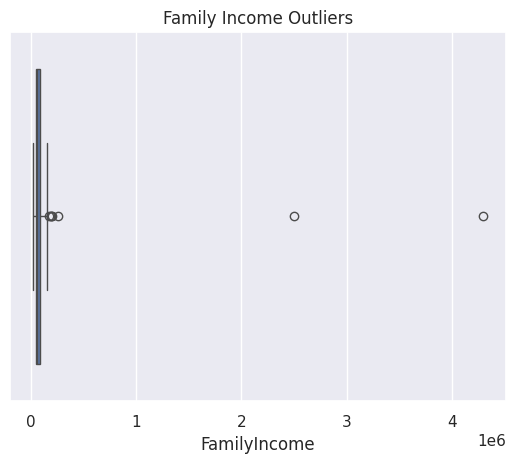


Unique values in Department:
['IT' 'AI' 'CS' 'DS' 'SE']

Unique values in DropoutRisk:
['Medium' 'Low' 'High' 'high' ' Medium' 'LOW']

Unique values in ScholarshipStatus:
['No' 'Partial' 'yes' 'Yes' ' No']

Data cleaned!


/tmp/ipykernel_353/2277747894.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_353/2277747894.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

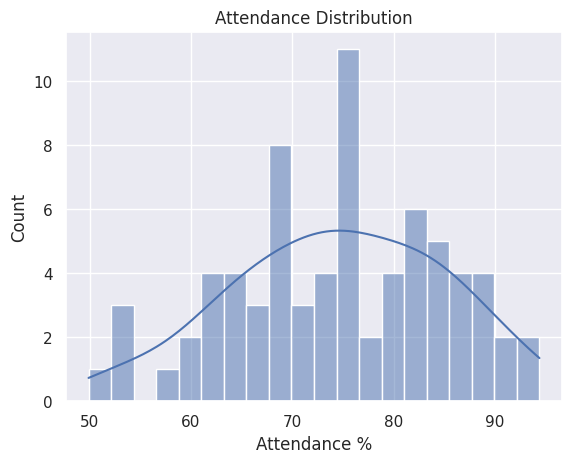

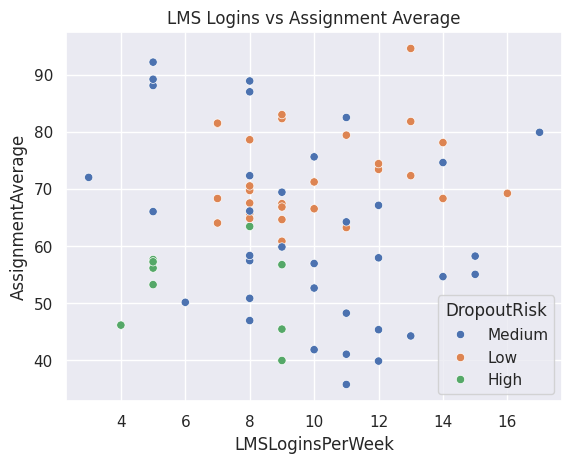

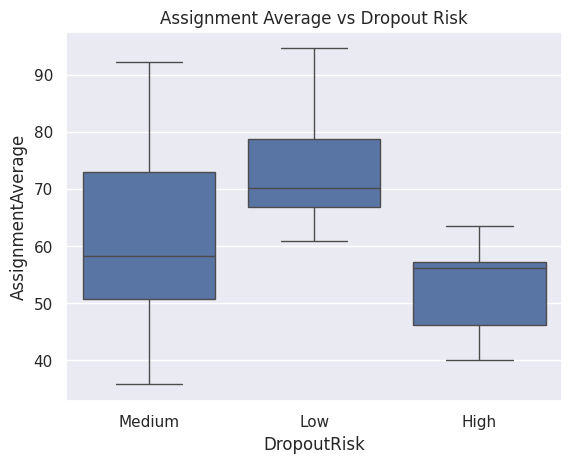


Crosstab:
DropoutRisk        High  Low  Medium
ScholarshipStatus                   
No                    2   16      24
Partial               5    7       3
Yes                   2    5       9


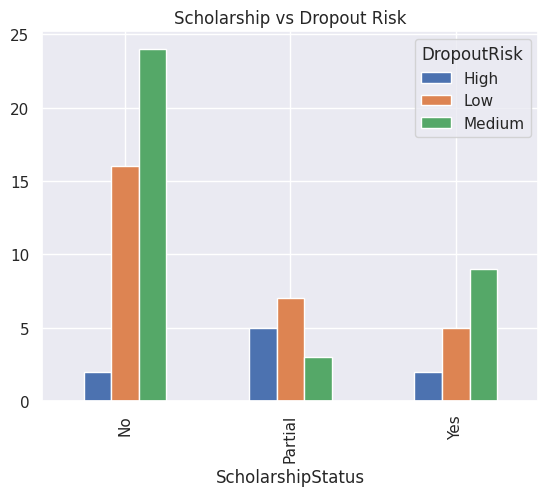


Final Data Preview:
  StudentID Department  AttendancePercent  LMSLoginsPerWeek  \
0     S2001         It               85.9              10.0   
1     S2002         It               86.1              11.0   
3     S2004         Ai               84.5               9.0   
5     S2006         Cs               80.5               5.0   
6     S2007         Ds               93.5               8.0   

   AssignmentAverage  FamilyIncome ScholarshipStatus DropoutRisk  
0               56.9      122686.0                No      Medium  
1               48.2       23996.0                No      Medium  
3               67.4      111267.0                No         Low  
5               57.6       47765.0           Partial        High  
6               46.9       32593.0           Partial      Medium  


In [ ]:
# STEP 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

# STEP 2. UPLOAD DATASET
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
print("Preview:")
print(df.head())

# STEP 3. DATASET STRUCTURE
print("\nDataset Info:")
df.info()
print("\nSummary:")
print(df.describe(include='all'))

# Identify variable types
print("\nColumn Types:")
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, "-> Categorical/ID")
    else:
        print(col, "-> Numerical")

# STEP 4. DATA QUALITY ISSUES
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Invalid Attendance (>100)
if 'AttendancePercent' in df.columns:
    print("\nInvalid Attendance:")
    print(df[df['AttendancePercent'] > 100])

# Extreme Income (check outliers)
if 'FamilyIncome' in df.columns:
    sns.boxplot(x=df['FamilyIncome'])
    plt.title("Family Income Outliers")
    plt.show()

# Category inconsistencies
for col in ['Department', 'DropoutRisk', 'ScholarshipStatus']:
    if col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].unique())

# STEP 5. DATA CLEANING
# Fill missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix attendance (>100)
if 'AttendancePercent' in df.columns:
    df = df[df['AttendancePercent'] <= 100]

# Standardize categories
for col in ['Department', 'DropoutRisk', 'ScholarshipStatus']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.capitalize()

# Remove extreme income outliers (IQR)
if 'FamilyIncome' in df.columns:
    Q1 = df['FamilyIncome'].quantile(0.25)
    Q3 = df['FamilyIncome'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df['FamilyIncome'] >= lower) & (df['FamilyIncome'] <= upper)]

print("\nData cleaned!")

# STEP 6. DISTRIBUTION PLOT (Attendance)
plt.figure()
sns.histplot(df['AttendancePercent'], bins=20, kde=True)
plt.title("Attendance Distribution")
plt.xlabel("Attendance %")
plt.show()

# STEP 7. SCATTER PLOT (LMS vs Assignment)
plt.figure()
sns.scatterplot(x='LMSLoginsPerWeek', y='AssignmentAverage', hue='DropoutRisk', data=df)
plt.title("LMS Logins vs Assignment Average")
plt.show()

# STEP 8. BOX PLOT (Assignment vs DropoutRisk)
plt.figure()
sns.boxplot(x='DropoutRisk', y='AssignmentAverage', data=df)
plt.title("Assignment Average vs Dropout Risk")
plt.show()

# STEP 9. CROSS TAB (Scholarship vs Dropout)
crosstab = pd.crosstab(df['ScholarshipStatus'], df['DropoutRisk'])
print("\nCrosstab:")
print(crosstab)
crosstab.plot(kind='bar')
plt.title("Scholarship vs Dropout Risk")
plt.show()

# STEP 10. FINAL DATA
print("\nFinal Data Preview:")
print(df.head())